## Generate astrophysical BNS population
This script generates a population of binary neutron star (BNS) systems based on astrophysical distributions for their masses, spins, and orbital parameters. The generated population can be used for simulations and analyses for kilonova.

1. **BNS population**
Sample masses from Gaussian distributions.
No need to sample spins.

2. **Calculate ejecta mass**
Calculate the ejecta mass using a fitting formula based on the masses of the neutron stars.
Neutron star EOS: SFHo
Ejecta mass: Dynamical ejecta + Wind ejecta

3. **Sample Observing angle**
Sample the observing angle uniformly in cos(theta) between 0 and 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18 as cosmo
np.random.seed(42)

#### Calculate number of BNS events
- BNS merger rate: 100 Gpc^-3 yr^-1
- Comoving volume up to z=0.2
- Observation time: 1 year
- Simulation times: 100 (Increase statistics)

N_events = merger_rate * V_comoving * T_obs * N_simulations = 387

In [2]:
N_samples = 387

#### Sample BNS mass
**Recycled NS** — double Gaussian mixture:

$$\pi(m) = \frac{\alpha}{\sigma_1\sqrt{2\pi}}\exp\!\left[-\left(\frac{m-\mu_1}{\sqrt{2}\,\sigma_1}\right)^{\!2}\right] + \frac{1-\alpha}{\sigma_2\sqrt{2\pi}}\exp\!\left[-\left(\frac{m-\mu_2}{\sqrt{2}\,\sigma_2}\right)^{\!2}\right]$$

with $\mu_1=1.34\,M_\odot$, $\mu_2=1.47\,M_\odot$, $\sigma_1=0.02\,M_\odot$, $\sigma_2=0.15\,M_\odot$, $\alpha=0.68$.

**Non-recycled NS** — Uniform in $[1.16,\,1.42]\,M_\odot$.

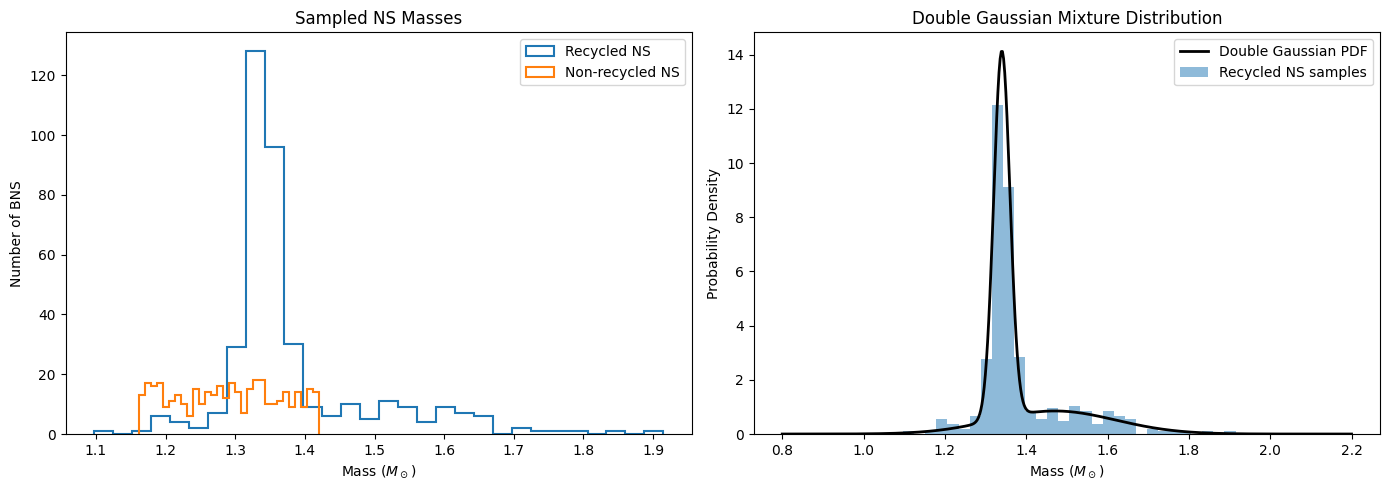

In [3]:
# Double Gaussian mixture for recycled NS mass (Eq. 11)
# π(m) = α/(σ1√2π) * exp(-(m-μ1)²/(2σ1²)) + (1-α)/(σ2√2π) * exp(-(m-μ2)²/(2σ2²))
np.random.seed(42)

mu1, sigma1 = 1.34, 0.02   # Component 1 parameters
mu2, sigma2 = 1.47, 0.15   # Component 2 parameters
alpha = 0.68                # Mixing weight

# Sample recycled NS masses from double Gaussian mixture
component = np.random.uniform(size=N_samples) < alpha
mass_recycled = np.where(component,
                         np.random.normal(mu1, sigma1, N_samples),
                         np.random.normal(mu2, sigma2, N_samples))

# Sample non-recycled NS masses from Uniform(1.16, 1.42)
mass_nonrecycled = np.random.uniform(1.16, 1.42, size=N_samples)

# Ensure mass1 >= mass2 by convention
mass1 = np.maximum(mass_recycled, mass_nonrecycled)
mass2 = np.minimum(mass_recycled, mass_nonrecycled)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: histograms of recycled / non-recycled masses
axes[0].hist(mass_recycled, bins=30, histtype='step', label='Recycled NS', linewidth=1.5)
axes[0].hist(mass_nonrecycled, bins=30, histtype='step', label='Non-recycled NS', linewidth=1.5)
axes[0].set_xlabel('Mass ($M_\\odot$)')
axes[0].set_ylabel('Number of BNS')
axes[0].set_title('Sampled NS Masses')
axes[0].legend()

# Panel 2: analytic double Gaussian PDF vs samples
m_grid = np.linspace(0.8, 2.2, 500)
pdf = (alpha / (sigma1 * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((m_grid - mu1) / sigma1)**2)
     + (1 - alpha) / (sigma2 * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((m_grid - mu2) / sigma2)**2))
axes[1].plot(m_grid, pdf, 'k-', linewidth=2, label='Double Gaussian PDF')
axes[1].hist(mass_recycled, bins=30, density=True, alpha=0.5, label='Recycled NS samples')
axes[1].set_xlabel('Mass ($M_\\odot$)')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('Double Gaussian Mixture Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

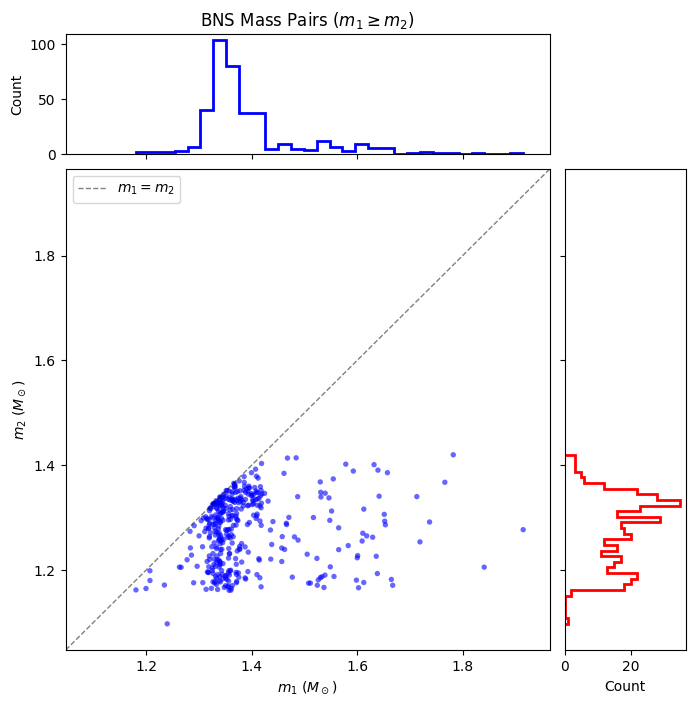

In [4]:
# 2D scatter of BNS mass pairs with marginal histograms
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      hspace=0.05, wspace=0.05)

ax_main = fig.add_subplot(gs[1, 0])
ax_top  = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

# Main scatter plot
ax_main.scatter(mass1, mass2, s=15, alpha=0.6, c='blue', edgecolors='none')
m_lim = [min(mass1.min(), mass2.min()) - 0.05, max(mass1.max(), mass2.max()) + 0.05]
ax_main.plot(m_lim, m_lim, 'k--', lw=1, alpha=0.5, label='$m_1 = m_2$')
ax_main.set_xlabel('$m_1$ ($M_\\odot$)')
ax_main.set_ylabel('$m_2$ ($M_\\odot$)')
ax_main.set_xlim(m_lim)
ax_main.set_ylim(m_lim)
ax_main.legend(loc='upper left')

# Top marginal histogram (mass1) — unfilled
ax_top.hist(mass1, bins=30, histtype='step', color='blue', linewidth=2)
ax_top.set_ylabel('Count')
ax_top.set_title('BNS Mass Pairs ($m_1 \\geq m_2$)')
ax_top.tick_params(labelbottom=False)

# Right marginal histogram (mass2) — unfilled, horizontal
ax_right.hist(mass2, bins=30, histtype='step', color='red', linewidth=2, orientation='horizontal')
ax_right.set_xlabel('Count')
ax_right.tick_params(labelleft=False)

# Hide unused corner
fig.add_subplot(gs[0, 1]).set_visible(False)

plt.show()

#### Calculate kilonova parameters

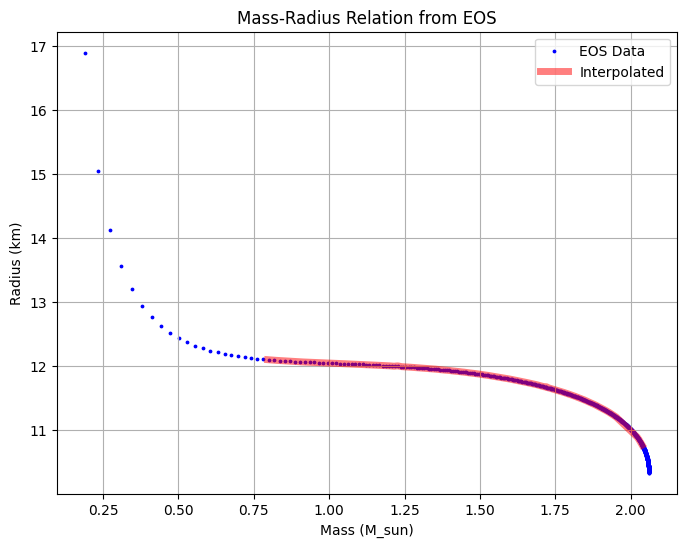

In [5]:
eos = pd.read_csv('eos.mr', names=['radius', 'mass'], sep='\s+', skiprows=1)

mass = eos['mass'].values
radius = eos['radius'].values
f = interp1d(mass, radius, kind='cubic', fill_value="extrapolate")
mass_inter = np.sort(np.random.normal(1.4, 0.2, size=1000))
radius1 = f(mass_inter)

plt.figure(figsize=(8,6))
plt.scatter(mass, radius, label='EOS Data', color='b',s=3)
plt.plot(mass_inter, radius1, label='Interpolated', color='r', alpha=0.5, linewidth=5)
plt.xlabel('Mass (M_sun)')
plt.ylabel('Radius (km)')
plt.title('Mass-Radius Relation from EOS')
plt.legend()
plt.grid()

In [6]:
def compute_compactness(mass, radius):

    G = 6.67430e-11  # m^3 kg^-1 s^-2
    c = 299792458    # m/s
    Ms = 1.98855e30  # kg
    C = (G * mass * Ms) / (c**2 * radius * 1000)  # radius in km to m
    return np.around(C, decimals=5)

radius1 = np.around(f(mass1),decimals=6)
radius2 = np.around(f(mass2),decimals=6)
compactness1 = compute_compactness(mass1, radius1)
compactness2 = compute_compactness(mass2, radius2)

#### Compute ejecta mass
In Bulla KN model, ejecta has two components: dynamical ejecta and wind ejecta. We can calculate them with gravitational wave parameters. 

Reference: *Predictions for electromagnetic counterparts to Neutron Star mergers discovered during LIGO-Virgo-KAGRA observing runs 4 and 5*

For dynamical ejecta mass, 
$log_{10}(m^{dyn fit}_{ej})=[a\frac{(1-2C_1)M_1}{C_1}+bM_2(\frac{M_1}{M_2})^n+\frac{d}{2}]+[1\leftrightarrow 2]$
, where $a=-0.0719, b=0.2116, d=-2.42, n=-2.905$;

$C=\frac{GW}{c^2R}$

In [7]:
def dynamical_ejecta_mass(m1, m2, c1, c2):
    a = -0.0719
    b = 0.2116
    d = -2.42
    n = -2.905
    
    term1 = (a * (1 - 2 * c1) * m1 / c1) + (b * m2 * (m1 / m2) ** n) + (d / 2)
    term2 = (a * (1 - 2 * c2) * m2 / c2) + (b * m1 * (m2 / m1) ** n) + (d / 2)
    
    log_mej_dyn = term1 + term2
    mej_dyn = 10 ** log_mej_dyn
    
    return mej_dyn

Dynamical Ejecta Mass(M_sun):
Mean: 0.0027511769543039077


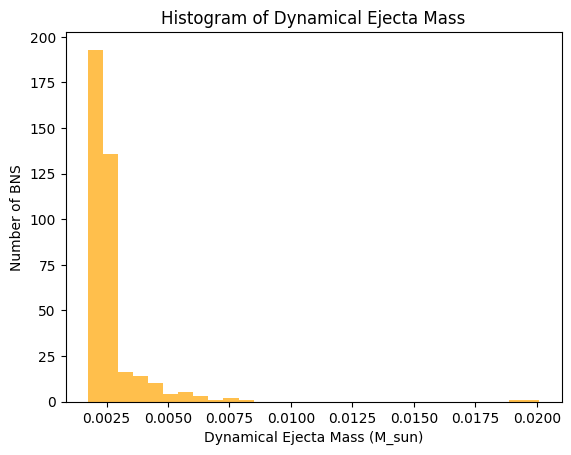

In [8]:
mej_dyn_fit = dynamical_ejecta_mass(mass1, mass2, compactness1, compactness2)
mej_dyn = np.minimum(0.09, mej_dyn_fit)

print("Dynamical Ejecta Mass(M_sun):")
print("Mean:", np.mean(mej_dyn))

# plot histogram of dynamical ejecta mass
plt.hist(mej_dyn, bins=30, color='orange', alpha=0.7)
plt.xlabel('Dynamical Ejecta Mass (M_sun)')
plt.ylabel('Number of BNS')
plt.title('Histogram of Dynamical Ejecta Mass')
plt.show()

For wind ejcta mass:

$m_{ej}^{wind}=\zeta m_{disc}$, $\zeta$ is sampled uniformly from $[0.1,0.4]$;

$log_{10}(m_{disk})=max(-3,a(1+b \cdot \tanh[\frac{c-(M_1+M_2)/M_{thr}}{d}]))$,where $a=-31.335,b=-0.9760,c=1.0474,d=0.05957$;

$M_{thr} = (2.38-3.606\frac{M_{TOV}}{R_{1.6M_{\odot}}})M_{TOV}$,$M_{TOV}=2.05M_{\odot}$

In [9]:
def compute_wind_ejecta_mass(m1, m2, Mthr, zeta):
    a = -31.335
    b = -0.9760
    c = 1.0474
    d = 0.05957
    
    Mtot = m1 + m2
    log_mdisk = np.maximum(-3, a * (1 + b * np.tanh((c - Mtot / Mthr) / d)))
    mdisk = 10 ** log_mdisk
    
    mej_wind = zeta * mdisk
    return mej_wind

Radius at 1.6M_sun R_1.6(km): 11.790587325737482
Threshold Mass M_thr(M_sun): 3.593719243296717
Wind Ejecta Mass(M_sun):
  - Mean: 0.04290354527913356


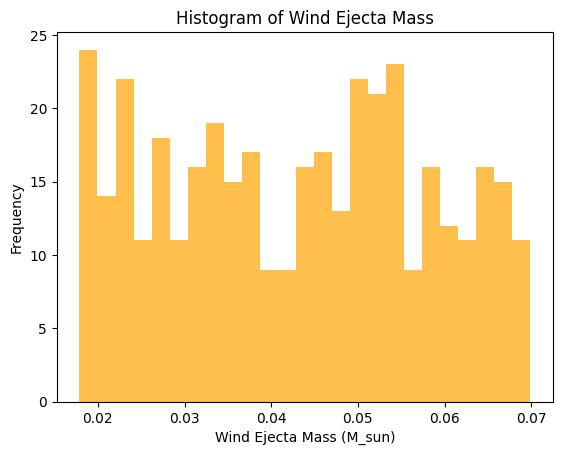

In [10]:
Rthr = f(1.6)
MTOV = 2.05  # in solar masses
Mthr = (2.38 - 3.606 * (MTOV / Rthr)) * MTOV
print("Radius at 1.6M_sun R_1.6(km):", Rthr)
print("Threshold Mass M_thr(M_sun):", Mthr)

np.random.seed(42)
zeta = np.random.uniform(0.1, 0.4, size=len(mass1))
mej_wind = compute_wind_ejecta_mass(mass1, mass2, Mthr, zeta)

print("Wind Ejecta Mass(M_sun):")
print("  - Mean:", np.mean(mej_wind))

# plot histogram of wind ejecta mass
plt.hist(mej_wind, bins=25, color='orange', alpha=0.7)
plt.xlabel('Wind Ejecta Mass (M_sun)')  
plt.ylabel('Frequency')
plt.title('Histogram of Wind Ejecta Mass')
plt.show()

If $m_1+m_2 \geq M_{thr}$, set both dynamical and wind ejcta to zero.

In [11]:
index = np.where((mass1 + mass2) >= Mthr)[0]
print("Indices of BNS systems with total mass >= M_thr:", index)
mej_dyn[index] = 0
mej_wind[index] = 0

Indices of BNS systems with total mass >= M_thr: []


Plot the distributions of dynamical ejecta mass and wind ejecta mass.

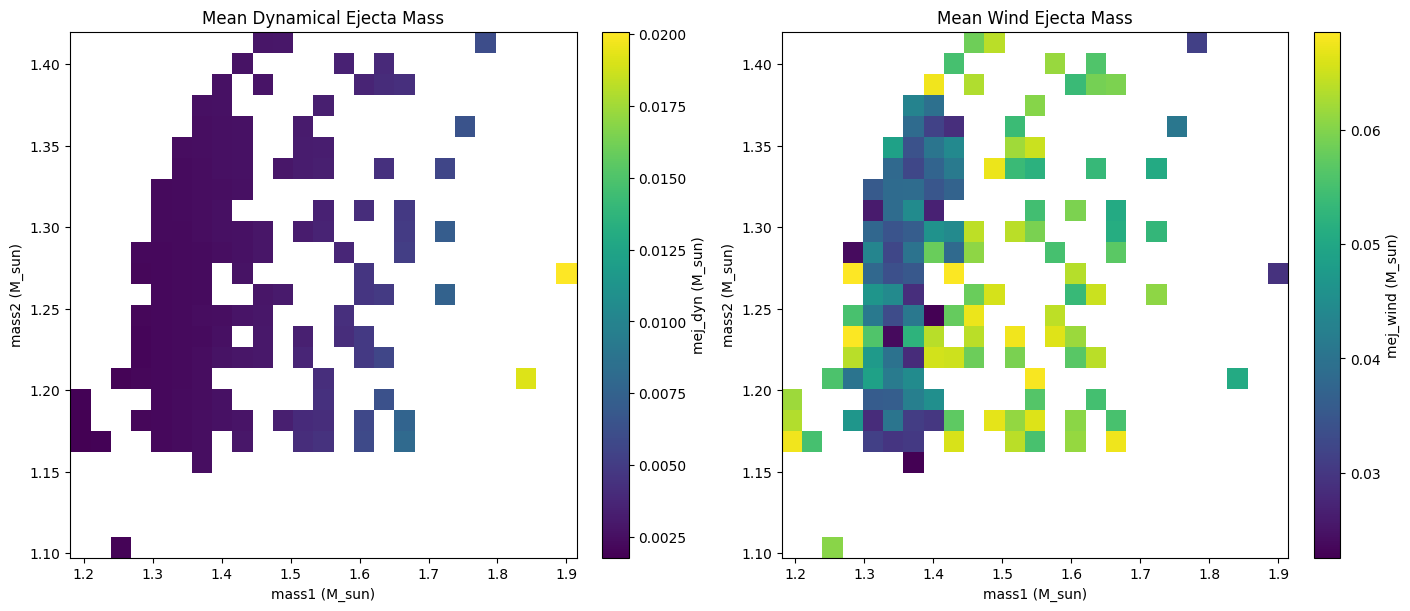

In [12]:
# Heatmaps of ejecta masses vs (mass1, mass2)
bins = 25

# 2D mean for dynamical ejecta
H_sum_dyn, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_dyn)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean_dyn = H_sum_dyn / np.where(H_count == 0, np.nan, H_count)

# 2D mean for wind ejecta
H_sum_wind, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges], weights=mej_wind)
H_mean_wind = H_sum_wind / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean_dyn.T, cmap='viridis', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Dynamical Ejecta Mass')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mej_dyn (M_sun)')

im1 = axs[1].pcolormesh(xedges, yedges, H_mean_wind.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Mean Wind Ejecta Mass')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('mej_wind (M_sun)')

plt.show()

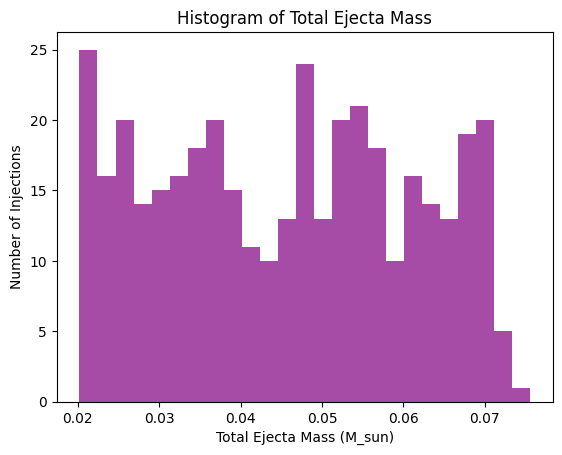

In [13]:
# total mass of ejecta
mej_total = mej_dyn + mej_wind

plt.hist(mej_total, bins=25, color='purple', alpha=0.7)
plt.xlabel('Total Ejecta Mass (M_sun)')
plt.ylabel('Number of Injections')
plt.title('Histogram of Total Ejecta Mass')
plt.show()

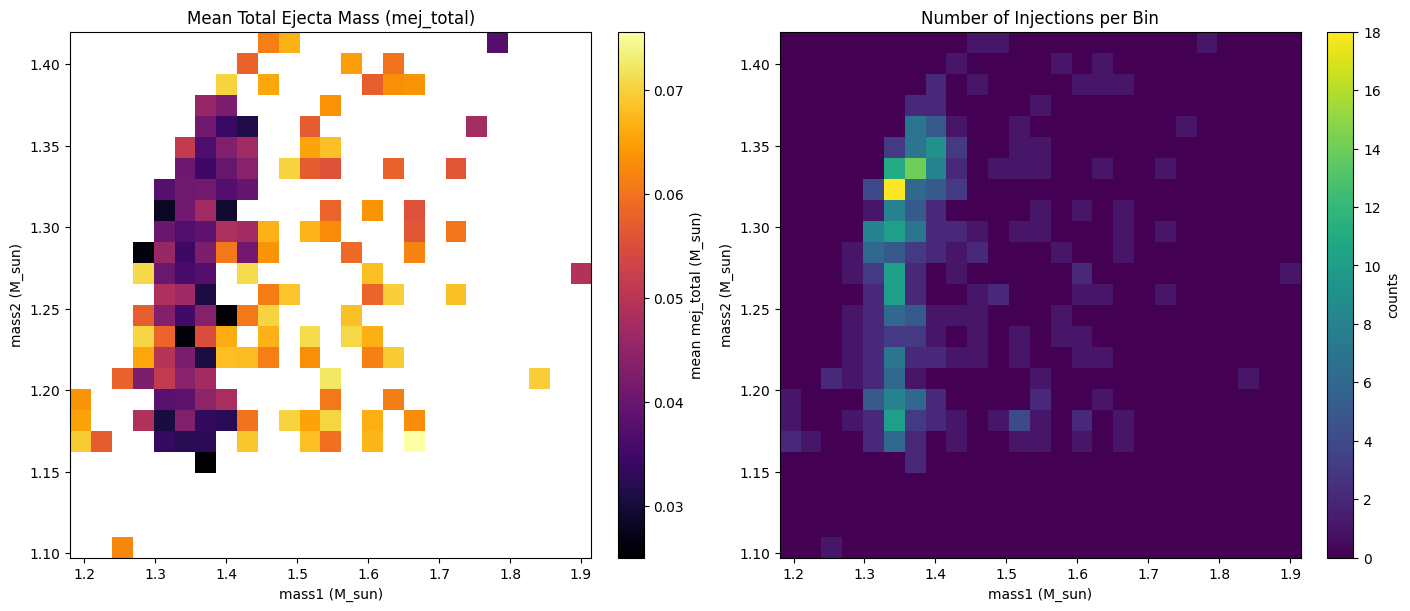

In [14]:
# 2D mean (and count) of total ejecta mass vs (mass1, mass2)
bins = 25

H_sum, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_total)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean = H_sum / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean.T, cmap='inferno', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Total Ejecta Mass (mej_total)')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mean mej_total (M_sun)')

# show counts in the other panel
im1 = axs[1].pcolormesh(xedges, yedges, H_count.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Number of Injections per Bin')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('counts')

plt.show()

Minimum and Maximum of dynamical ejcta mass: 0.0017550718278826107 0.020087902005171306
Minimum and Maximum of wind ejcta mass: 0.017873410194107927 0.06989874086851035
Model range of dynamical ejcta mass:[0.001,0.02]
Model range of wind ejcta mass:[0.01,0.13]


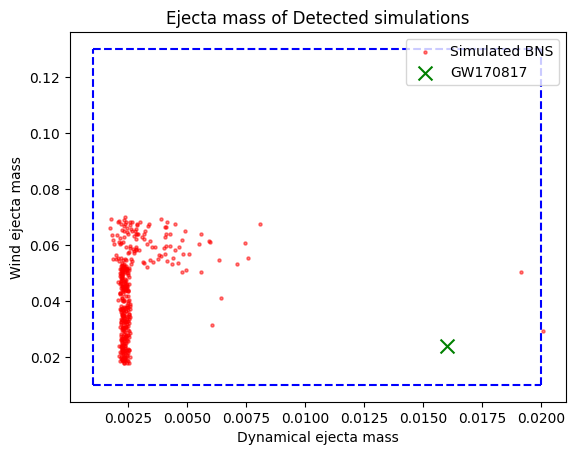

In [15]:
plt.scatter(mej_dyn,mej_wind,color='r',alpha=0.5,s=5,label='Simulated BNS')
plt.xlabel("Dynamical ejecta mass")
plt.ylabel("Wind ejecta mass")
plt.vlines(x=[0.001,0.02],ymin=0.01,ymax=0.13,colors='b',ls='--')
plt.hlines(y=[0.01,0.13],xmin=0.001,xmax=0.02,colors='b',ls='--')
plt.scatter(x=0.016,y=0.024,marker='x',color='g',s=100,label='GW170817')
plt.title("Ejecta mass of Detected simulations")
plt.legend()
print("Minimum and Maximum of dynamical ejcta mass:", min(mej_dyn),max(mej_dyn))
print("Minimum and Maximum of wind ejcta mass:", min(mej_wind),max(mej_wind))
print("Model range of dynamical ejcta mass:[0.001,0.02]")
print("Model range of wind ejcta mass:[0.01,0.13]")

#### Sample observing angle

In [16]:
np.random.seed(42)
cos_theta = np.random.uniform(0, 1, size=N_samples)

Redshift range: 0.0333 - 0.1993


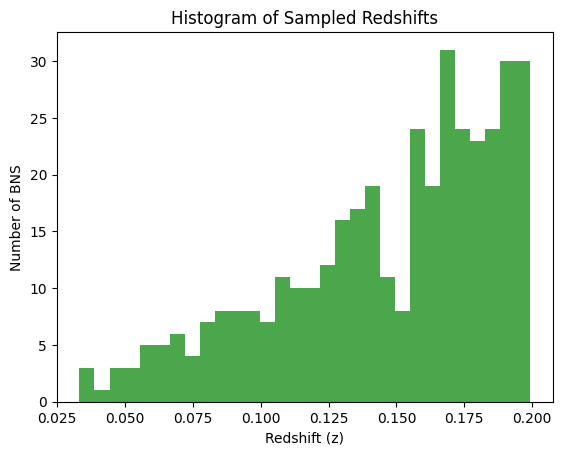

In [17]:
# Sample redshift from uniform comoving volume within [zmin, zmax]
zmin, zmax = 0.01, 0.2
z_grid = np.linspace(zmin, zmax, 5000)
V = cosmo.comoving_volume(z_grid).value

np.random.seed(42)
u = np.random.uniform(V.min(), V.max(), size=N_samples)
redshift = np.interp(u, V, z_grid)

print(f"Redshift range: {redshift.min():.4f} - {redshift.max():.4f}")

# plot histogram of redshift
plt.hist(redshift, bins=30, color='green', alpha=0.7)
plt.xlabel('Redshift (z)')
plt.ylabel('Number of BNS')
plt.title('Histogram of Sampled Redshifts')
plt.show()

#### Sample redshift
Sample redshift uniformly in comoving volume up to z=0.2.

#### Save the ejecta masses to csv file

In [18]:
df = pd.DataFrame({
    'event_id': np.arange(1, N_samples + 1),
    'mass1': mass1,
    'mass2': mass2,
    'mej_dyn': mej_dyn,
    'mej_wind': mej_wind,
    'mej_total': mej_total,
    'cos_theta': cos_theta,
    'redshift': redshift
})

output_file = '../results/Astrophysical/bns_population.csv'
df.to_csv(output_file, index=False)
print(f"Data saved to {output_file}")
print(f"Total number of events: {len(df)}")
print("\nFirst 5 rows:")
print(df.head())

Data saved to ../results/Astrophysical/bns_population.csv
Total number of events: 387

First 5 rows:
   event_id     mass1     mass2   mej_dyn  mej_wind  mej_total  cos_theta  \
0         1  1.351035  1.189099  0.002329  0.037530   0.039859   0.374540   
1         2  1.505198  1.230135  0.003380  0.067541   0.070920   0.950714   
2         3  1.507913  1.174843  0.003828  0.056241   0.060070   0.731994   
3         4  1.315589  1.298104  0.002211  0.049338   0.051548   0.598658   
4         5  1.403517  1.326616  0.002501  0.025751   0.028253   0.156019   

   redshift  
0  0.142067  
1  0.196481  
2  0.179295  
3  0.167156  
4  0.105147  
